In [ ]:
# CELL 1: Imports and Load Dataset
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training images shape :", x_train.shape)
print("Training labels shape :", y_train.shape)
print("Test images shape     :", x_test.shape)
print("Test labels shape     :", y_test.shape)
print("Pixel value range     :", x_train.min(), "–", x_train.max())
print("Classes               :", class_names)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step
Training images shape : (50000, 32, 32, 3)
Training labels shape : (50000, 1)
Test images shape     : (10000, 32, 32, 3)
Test labels shape     : (10000, 1)
Pixel value range     : 0 – 255
Classes               : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# CELL:9
# MEMBER 3: Outlier Removal
# Step 1: Detect degenerate images (all pixels the same value = corrupted)
flat_mask = np.array([img.min() == img.max() for img in x_train])
print("Degenerate (outlier) images found:", flat_mask.sum())

# Step 2: Remove them if found
if flat_mask.sum() > 0:
    x_train_clean = x_train[~flat_mask]
    y_train_clean = y_train[~flat_mask]
    print(f"Removed {flat_mask.sum()} outlier images")
else:
    x_train_clean = x_train
    y_train_clean = y_train
    print("No outlier images found — none removed")

Degenerate (outlier) images found: 0
No outlier images found — none removed


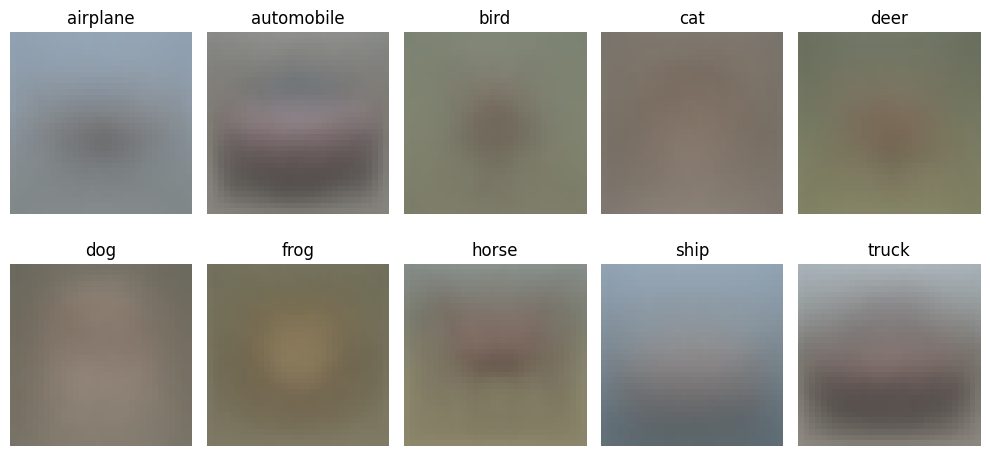

In [ ]:
# CELL 10: Average image per class
x_train_norm = x_train.astype('float32') / 255.0  # recreate in case runtime reset

plt.figure(figsize=(10, 5))
for i, name in enumerate(class_names):
    class_images = x_train_norm[y_train.flatten() == i]
    avg_image = class_images.mean(axis=0)
    plt.subplot(2, 5, i + 1)
    plt.imshow(avg_image)
    plt.title(name)
    plt.axis('off')
plt.tight_layout()
plt.show()